# CT denoising reconstructing #
---
# Part 0: Modulation import




In [2]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from sktime.datasets import load_from_tsfile

---
# Part 1: Simulated signal generation
In this part, functions how to generating the signals are demonstrated. And also the metrics to compare the denoising affect of differents are shown.

## 1. Signal generation

In [3]:
def generate_advanced_ppg(num_samples=3000, fs=100, heart_rate=60, 
                          a1=1.0000, theta1=-1.5161, b1=0.6303, 
                          a2=0.1999, theta2=0.8186, b2=1.0225):
    duration = num_samples / fs
    num_beats = duration * (heart_rate / 60.0)
    total_math_time = num_beats * 6.0
    t_math = np.linspace(0, total_math_time, num_samples)
    t_p = (t_math % 6.0) - 3.0
    pure_signal = (a1 * np.exp(-0.5 * ((t_p - theta1) / b1)**2) + 
                   a2 * np.exp(-0.5 * ((t_p - theta2) / b2)**2))
    return pure_signal



## 2. Metrics generation

In [4]:
def evaluate_performance(pure_signal, noisy_signal, denoised_signal):
    signal_power = np.sum(pure_signal**2)
    noise_power_out = np.sum((pure_signal - denoised_signal)**2)
    noise_power_in = np.sum((pure_signal - noisy_signal)**2)
    
    snr_out = 10 * np.log10(signal_power / noise_power_out) if noise_power_out != 0 else np.inf
    snr_in = 10 * np.log10(signal_power / noise_power_in) if noise_power_in != 0 else np.inf
    rmse = np.sqrt(np.mean((pure_signal - denoised_signal)**2))
    prd = np.sqrt(np.sum((pure_signal - denoised_signal)**2) / signal_power) * 100
    
    return snr_in, snr_out, rmse, prd

---
# Part 2: Algorithms design
In this part, functions with three methods: Discrete Wavelet Transform (DWT), DWT based on Crest Factor and Wavelet Packet Transform (PWT) are implemented.
## 1. Method based on Discrete Wavelet Transform 

In [5]:
def dwt_denoising_baseline(noisy_signal, wavelet='db4', level=5):

    signal_length = len(noisy_signal)
    max_possible = pywt.dwt_max_level(signal_length, pywt.Wavelet(wavelet).dec_len)
    actual_level = min(level, max_possible)
    

    coeffs = pywt.wavedec(noisy_signal, wavelet, level=actual_level)
    
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745

    uthresh = sigma * np.sqrt(2 * np.log(signal_length))

    denoised_coeffs = [coeffs[0]]
    for i in range(1, len(coeffs)):
        denoised_coeffs.append(pywt.threshold(coeffs[i], value=uthresh, mode='soft'))
        
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
    return denoised_signal[:signal_length], actual_level

## 2. Method based on Discrete Wavelet Transform using crest factor

In [6]:
def calculate_crest_factor(cd):
    rms = np.sqrt(np.mean(cd**2))
    if rms == 0:
        return 0
    return np.max(np.abs(cd)) / rms

def dwt_denoising_with_cf(noisy_signal, wavelet='db4', max_allowed_level=7):

    signal_length = len(noisy_signal)
    max_possible_level = min(pywt.dwt_max_level(signal_length, pywt.Wavelet(wavelet).dec_len), max_allowed_level)
    
    k_opt = 1
    for i in range(1, max_possible_level + 1):
        coeffs_temp = pywt.wavedec(noisy_signal, wavelet, level=i)
        cd_i = coeffs_temp[1] 
        cf_i = calculate_crest_factor(cd_i)
        
        if cf_i < 2.5:
            k_opt = max(1, i - 1)
            break
    else:
        k_opt = max_possible_level

    coeffs = pywt.wavedec(noisy_signal, wavelet, level=k_opt)
    cd_1 = coeffs[-1]
    cf_1 = calculate_crest_factor(cd_1)
    
    denoised_coeffs = [coeffs[0]] 
    
    for j in range(1, len(coeffs)):
        cd_j = coeffs[j]
        cf_j = calculate_crest_factor(cd_j)
        
        if cf_j >= 3.5:
            new_cd = np.zeros_like(cd_j) 
        elif 2.5 < cf_j <= 3.5:
            a = cf_j / cf_1 if cf_1 != 0 else 1
            gamma = a * np.max(np.abs(cd_j))
            new_cd = pywt.threshold(cd_j, gamma, mode='hard') 
        else:
            new_cd = cd_j
            
        denoised_coeffs.append(new_cd)
        
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
    return denoised_signal[:signal_length], k_opt

## 2. Method based on Wavelet Packet Transform 

In [7]:
def calculate_shannon_entropy(data):
    data_sq = data**2
    val = data_sq[data_sq > 1e-12]
    if len(val) == 0:
        return 0
    return -np.sum(val * np.log(val))

def wpt_denoising_with_entropy(noisy_signal, wavelet='db4', max_level=4, alpha=0.5):
    signal_length = len(noisy_signal)
    wp = pywt.WaveletPacket(data=noisy_signal, wavelet=wavelet, mode='symmetric', maxlevel=max_level)
    
    for current_level in range(max_level - 1, -1, -1):
        for node in wp.get_level(current_level, 'freq'):
            if node.is_empty:
                continue
            try:
                child_a = wp[node.path + 'a']
                child_d = wp[node.path + 'd']
            except KeyError:
                continue

            entropy_parent = calculate_shannon_entropy(node.data)
            entropy_children = calculate_shannon_entropy(child_a.data) + calculate_shannon_entropy(child_d.data)

            if entropy_parent <= entropy_children:
                del wp[child_a.path]
                del wp[child_d.path]

    try:
        noise_coeffs = wp['d'].data
    except (KeyError, ValueError):

        noise_coeffs = noisy_signal
        
    sigma = np.median(np.abs(noise_coeffs)) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(signal_length))


    for node in wp.get_leaf_nodes():
        if node.path == 'a' * len(node.path):
            continue 
            
        data = node.data
        denoised_data = np.zeros_like(data)

        mask = np.abs(data) >= threshold
        denoised_data[mask] = np.sign(data[mask]) * (np.abs(data[mask]) - alpha * threshold)
        
        node.data = denoised_data

    denoised_signal = wp.reconstruct(update=False)
    return denoised_signal[:signal_length], wp

---
# Part 3: Tools for comparsion
In this part, functions for making plots are demonstrated, which makes it easier to compare and clearly showcase the results on simulation results

In [8]:
def plot_comprehensive_results(t, noisy_signal, pure_signal, 
                               denoised_base, denoised_cf, denoised_wpt, 
                               signal_type, lvl_base, lvl_cf, 
                               so_base=None, so_cf=None, so_wpt=None):

    plt.figure(figsize=(15, 11))

    x_min = t[0] 
    x_max = min(30, t[-1]) 


    plt.subplot(4, 1, 1)
    plt.plot(t, noisy_signal, color='red', alpha=0.6, label='Raw Noisy Signal')

    if signal_type not in [5, 6]: 
        plt.plot(t, pure_signal, 'k--', label='Ground Truth')
        plt.title(f"Input Signal (AWGN + Baseline Wander)")
    else:
        plt.title(f"Real Measured PPG Signal (Type {signal_type})")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(x_min, x_max) 


    plt.subplot(4, 1, 2)
    plt.plot(t, noisy_signal, color='red', alpha=0.2)
    plt.plot(t, denoised_base, color='darkorange', linewidth=1.5, label=f'Baseline DWT (Level {lvl_base})')
    title_base = f"Method 1: Baseline DWT (Global Soft Thresh)"
    if so_base is not None: title_base += f" | SNR: {so_base:.2f}dB"
    plt.title(title_base)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(x_min, x_max)

    plt.subplot(4, 1, 3)
    plt.plot(t, noisy_signal, color='red', alpha=0.2)
    plt.plot(t, denoised_cf, color='blue', linewidth=1.5, label=f'CF-DWT (Level {lvl_cf})')
    title_cf = f"Method 2: Adaptive DWT (Crest Factor)"
    if so_cf is not None: title_cf += f" | SNR: {so_cf:.2f}dB"
    plt.title(title_cf)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(x_min, x_max)

    plt.subplot(4, 1, 4)
    plt.plot(t, noisy_signal, color='red', alpha=0.2)
    plt.plot(t, denoised_wpt, color='green', linewidth=1.5, label='WPT (Best Basis)')
    title_wpt = f"Method 3: WPT (Shannon Entropy)"
    if so_wpt is not None: title_wpt += f" | SNR: {so_wpt:.2f}dB"
    plt.title(title_wpt)
    plt.xlabel("Time (seconds)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(x_min, x_max)

    plt.tight_layout()
    plt.show()
    

---
# Part 4: Practical implementation


Signal 1-4 are simulated signals, Signal 5 is the real PPG signal, Signal 6 is the signal we have conducted

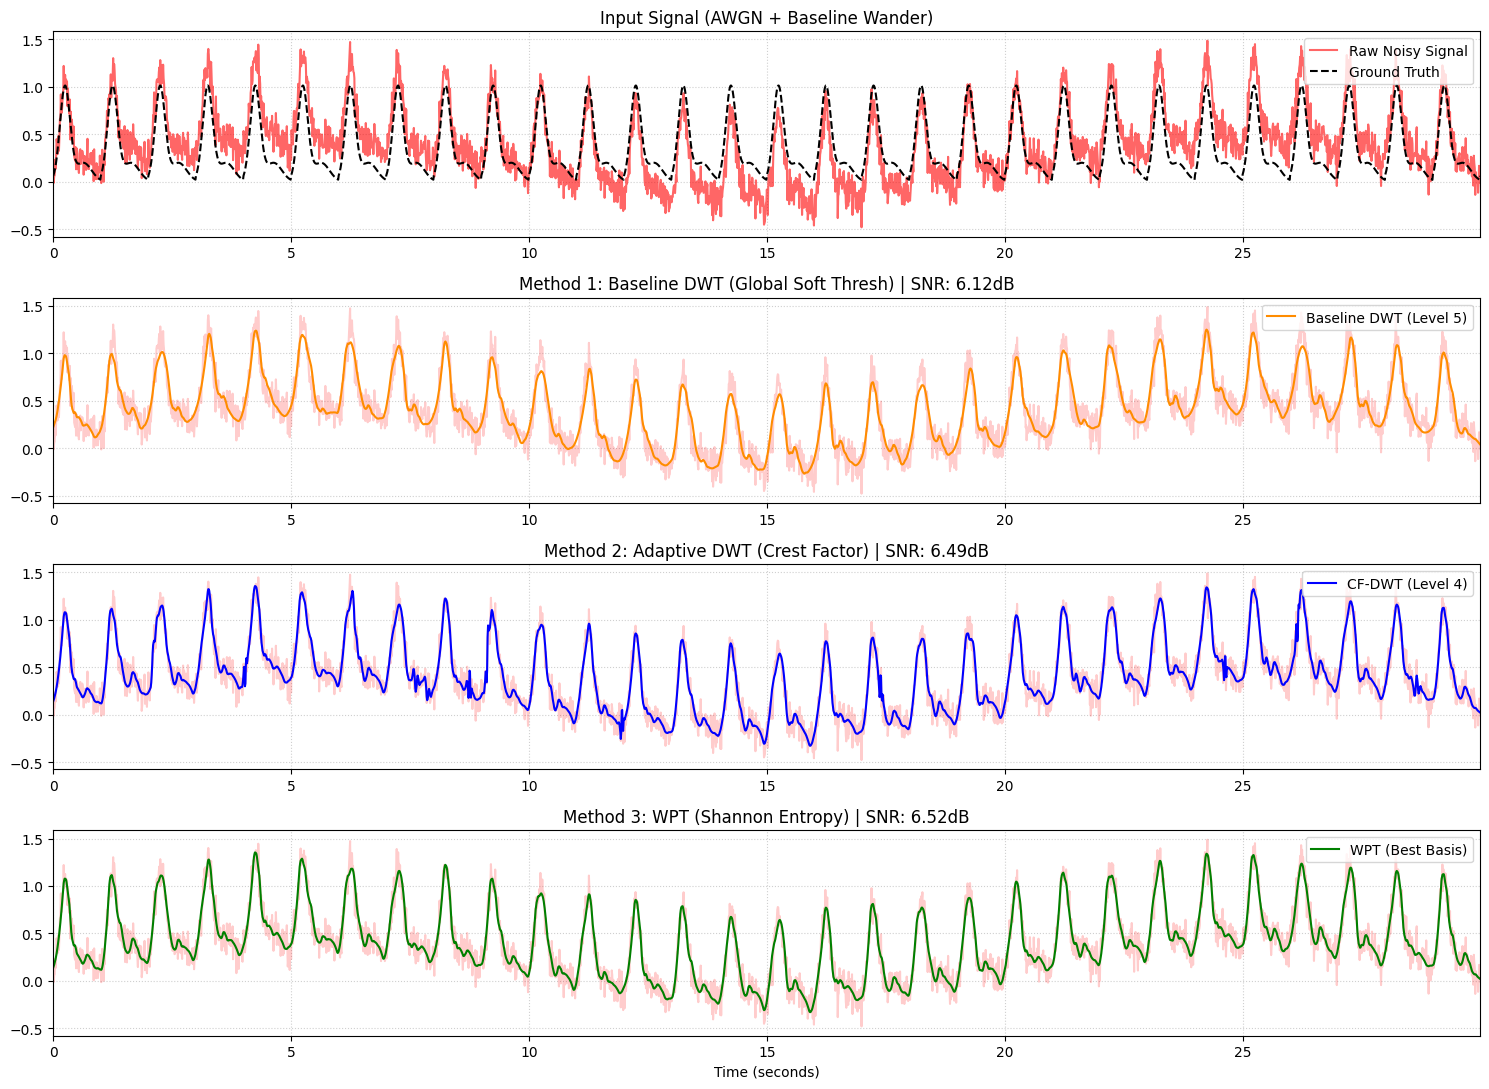

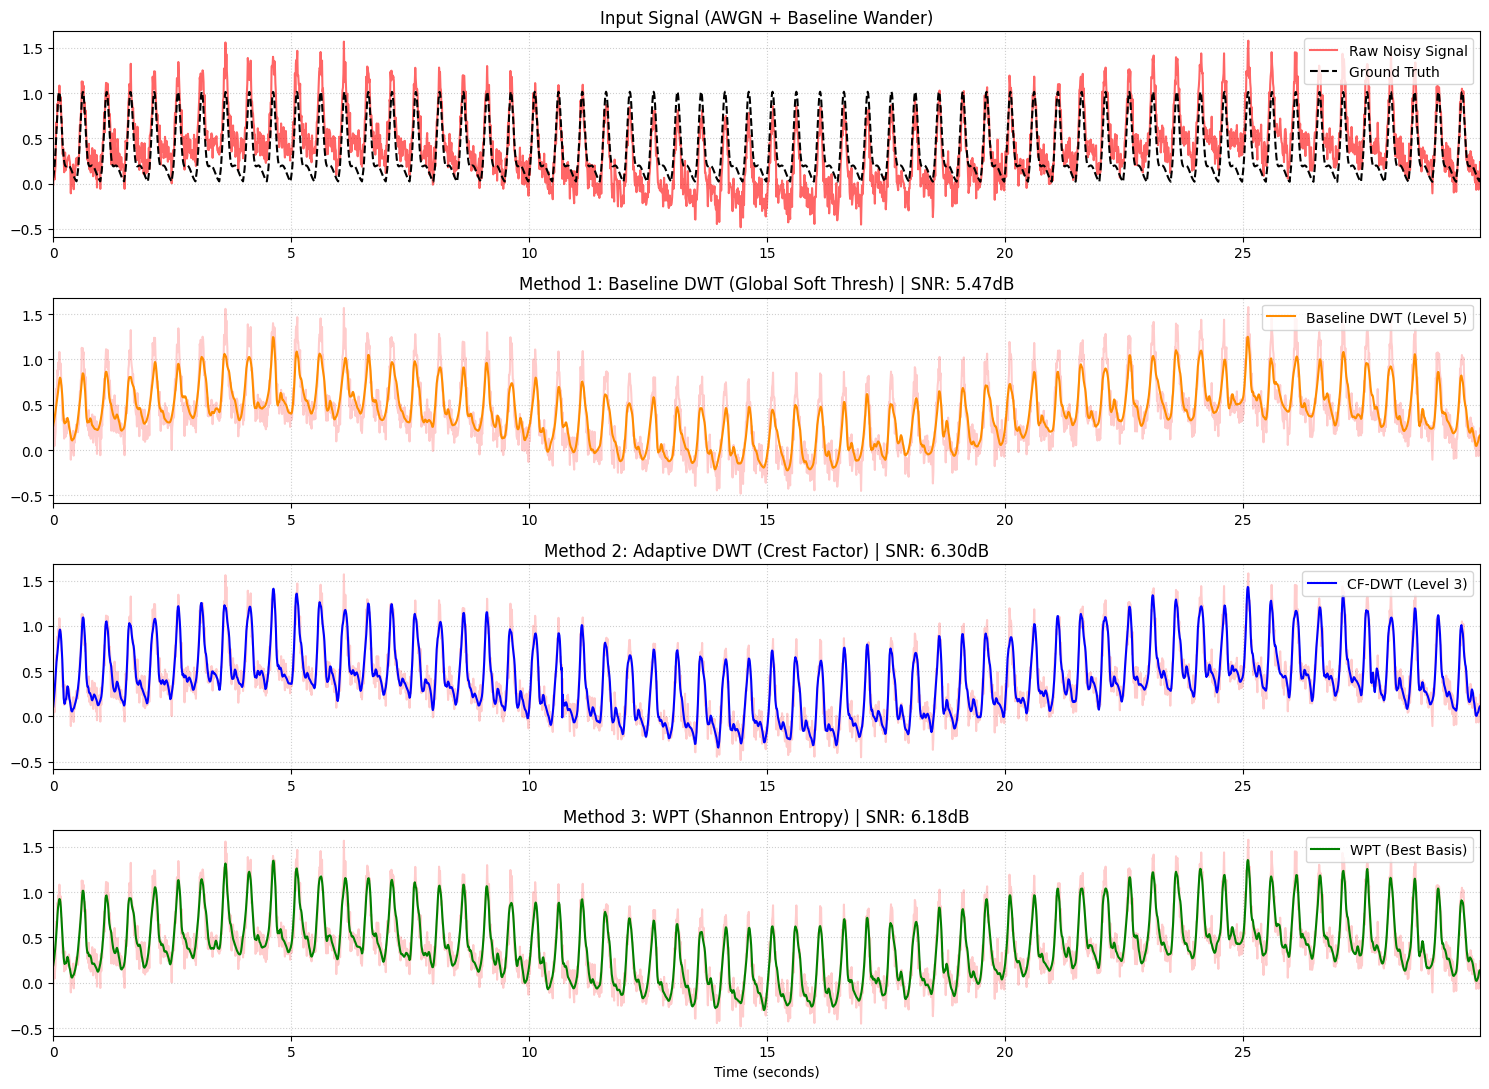

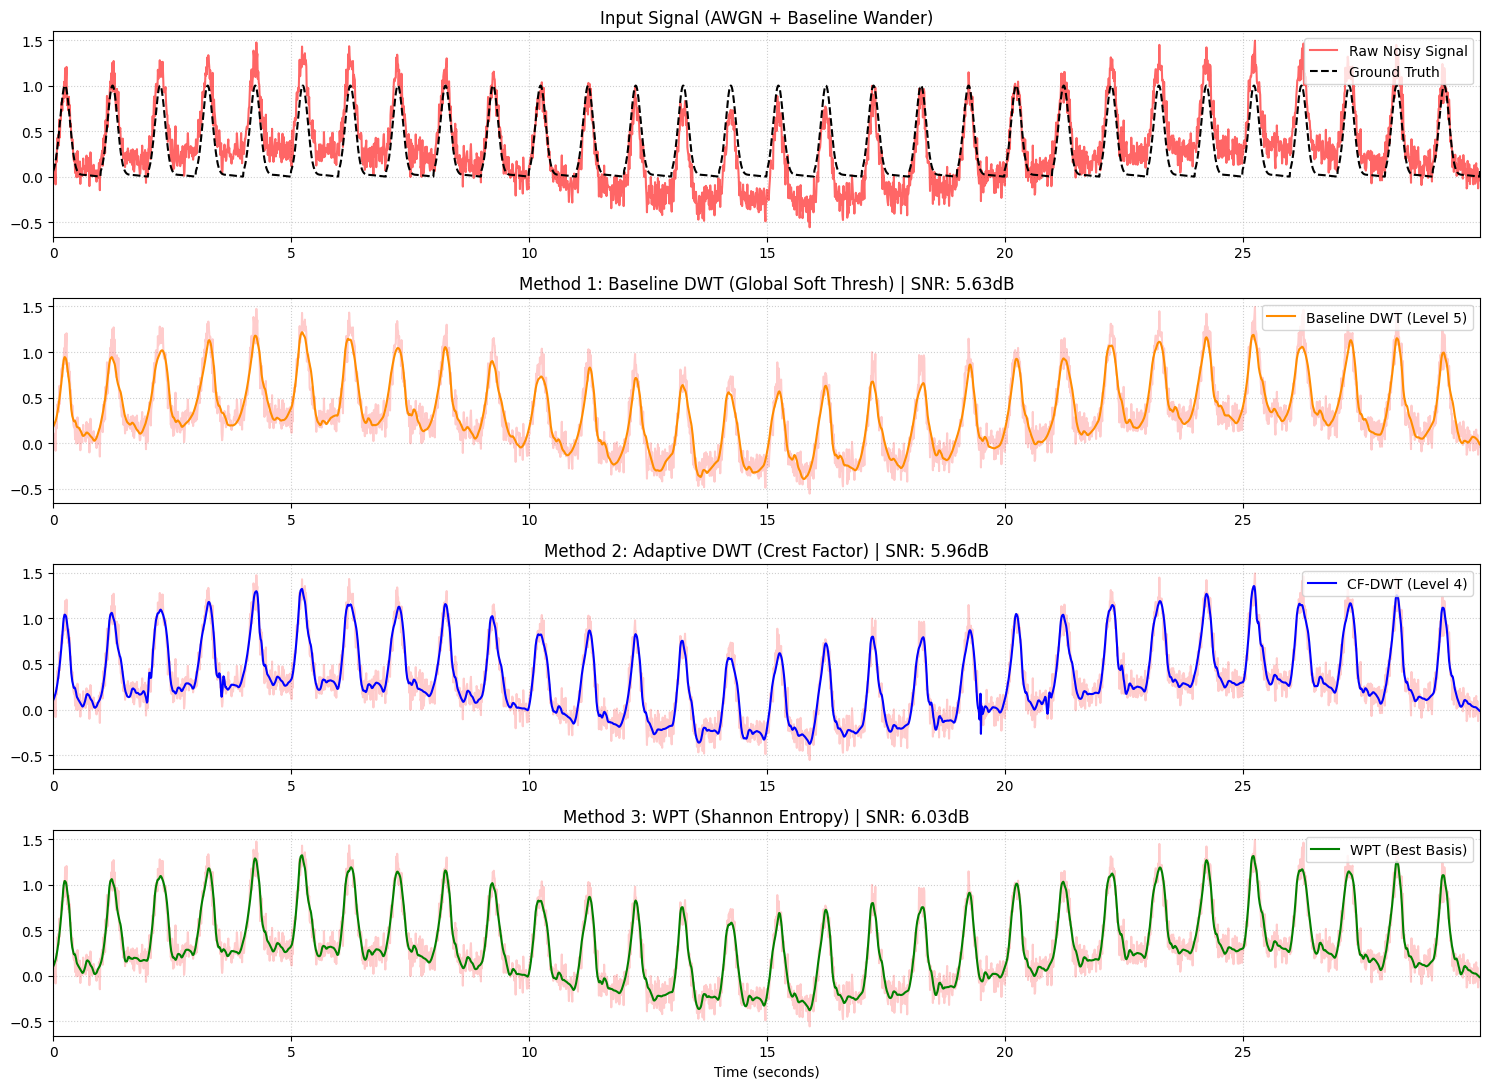

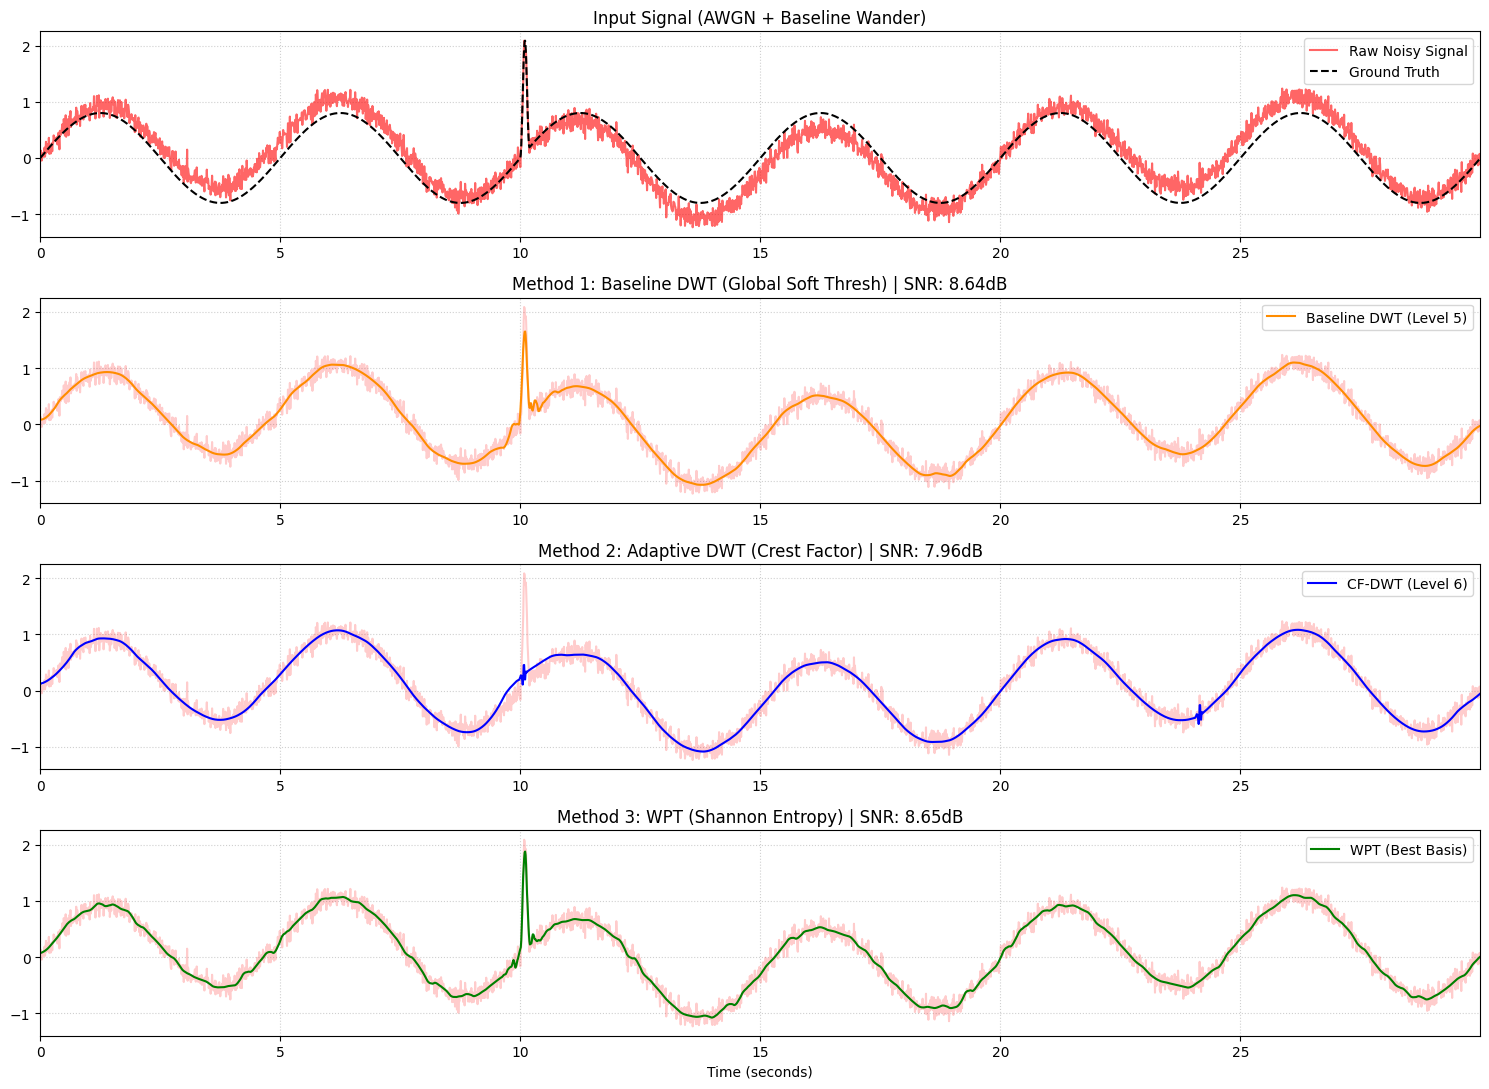

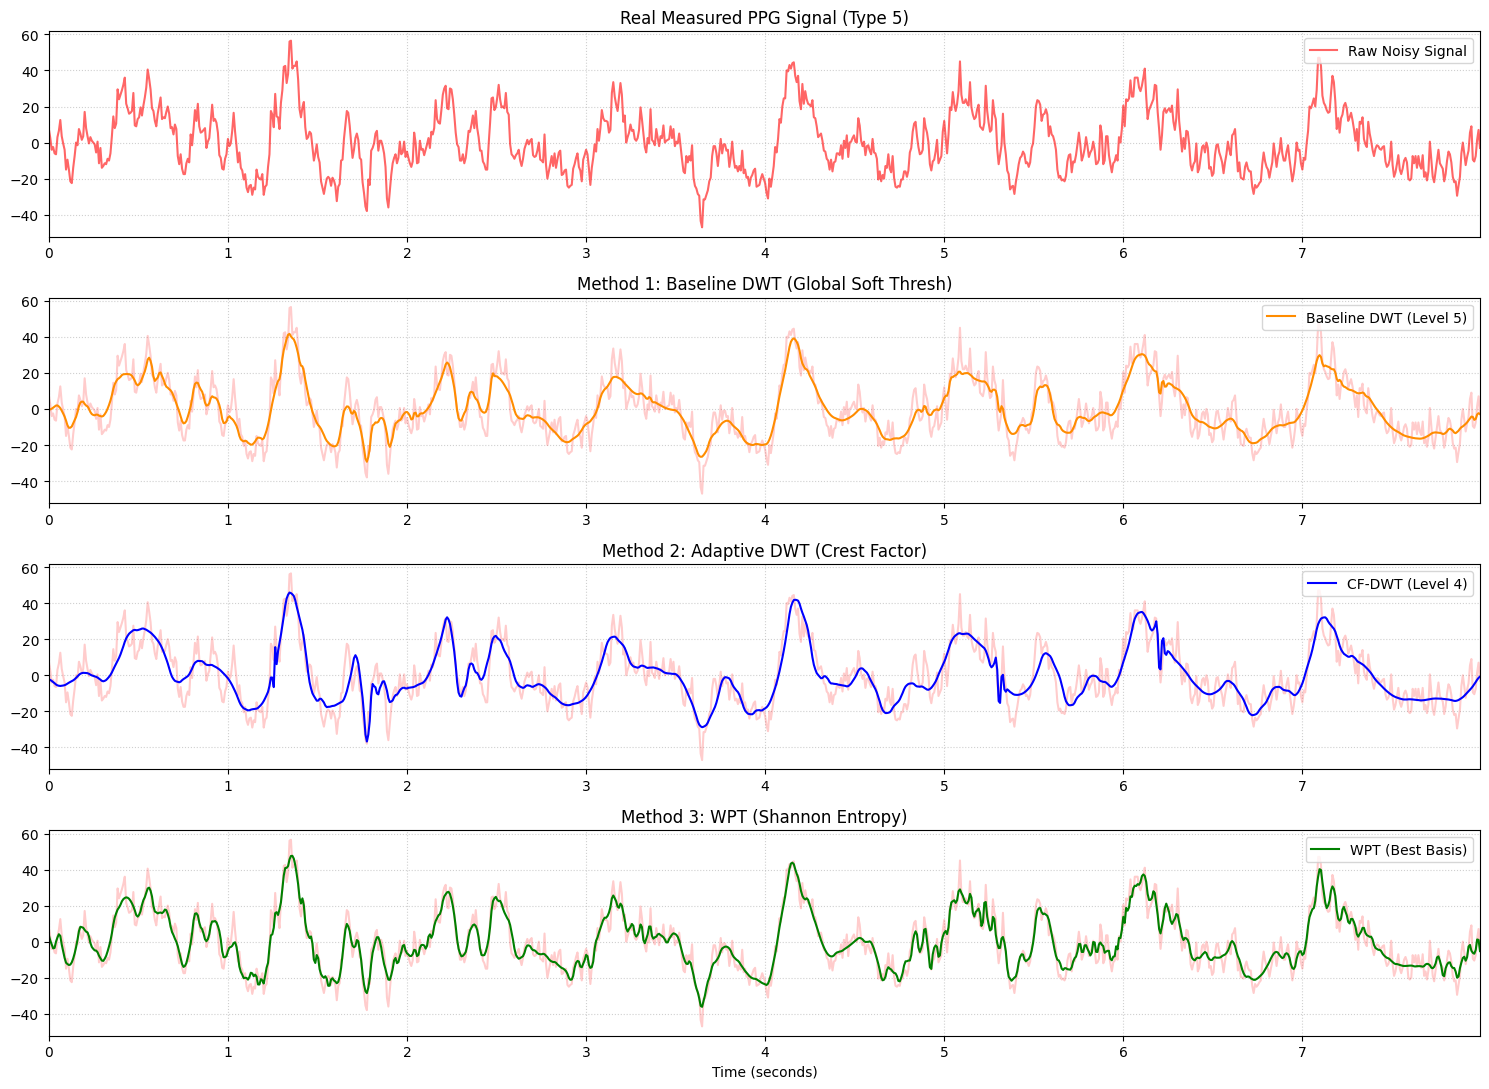

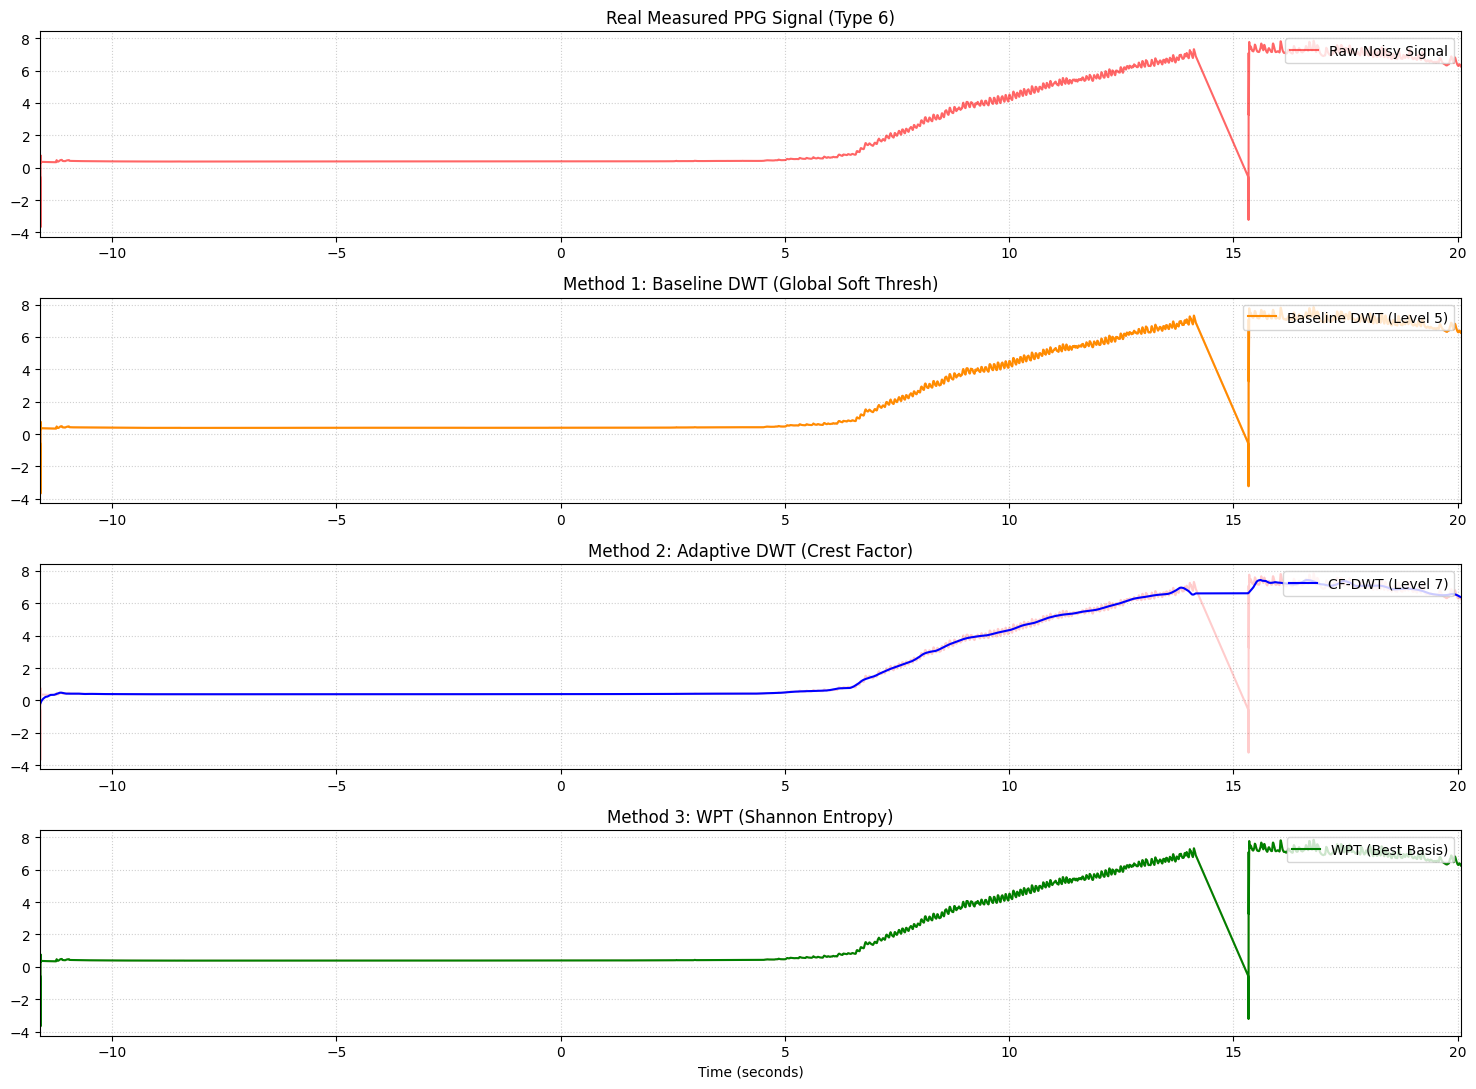

In [9]:
ts_file_path = "IEEEPPG_TEST.ts" 
sample_idx = 0           
channel_idx = 0           
wavelet_choice = 'db4'    

for i in range(1, 7):
    signal_type = i
    fs = 125
    if signal_type == 5:
        try:
            X, y = load_from_tsfile(ts_file_path, return_data_type="numpy3d")
            raw_data = X[sample_idx, channel_idx, :]
            noisy_signal = raw_data - np.mean(raw_data)
            num_samples = len(noisy_signal)
            t = np.arange(num_samples) / fs
            pure_signal = np.zeros(num_samples)
        except Exception as e:
            signal_type = 1 
            fs = 100
            
    elif signal_type == 6:  
        try:
            raw_data_full = np.loadtxt("SkinG_subject1.txt")
            t = raw_data_full[:, 0]
            raw_data = raw_data_full[:, 1]
            
            noisy_signal = raw_data * 1e6 
            
            num_samples = len(noisy_signal)
            pure_signal = np.zeros(num_samples)
        except Exception as e:
            signal_type = 1 
            fs = 100

    if signal_type not in [5, 6]: 
        fs = 100
        num_samples = 3000
        t = np.arange(num_samples) / fs
        
        if signal_type == 1:
            pure_signal = generate_advanced_ppg(num_samples, fs, heart_rate=60)
        elif signal_type == 2:
            pure_signal = generate_advanced_ppg(num_samples, fs, heart_rate=120) 
        elif signal_type == 3:
            pure_signal = generate_advanced_ppg(num_samples, fs, a2=0.02) 
        elif signal_type == 4:
            pure_signal = 0.8 * np.sin(2 * np.pi * 0.2 * t)
            pure_signal[1000:1020] += 2.0 * np.hanning(20)
        else:
            pure_signal = generate_advanced_ppg(num_samples, fs)
        
        np.random.seed(42 + i) 
        noise = np.random.normal(0, 0.1, num_samples)
        baseline_wander = 0.3 * np.sin(2 * np.pi * 0.05 * t)
        noisy_signal = pure_signal + noise + baseline_wander



    denoised_base, lvl_base = dwt_denoising_baseline(noisy_signal, wavelet=wavelet_choice, level=5)



    denoised_cf, lvl_cf = dwt_denoising_with_cf(noisy_signal, wavelet=wavelet_choice)



    denoised_wpt, _ = wpt_denoising_with_entropy(noisy_signal, wavelet=wavelet_choice, max_level=4)



    so_base, so_cf, so_wpt = None, None, None


    if signal_type not in [5, 6]: 
        si, so_base, rm_base, _ = evaluate_performance(pure_signal, noisy_signal, denoised_base)
        _,  so_cf,   rm_cf,   _ = evaluate_performance(pure_signal, noisy_signal, denoised_cf)
        _,  so_wpt,  rm_wpt,  _ = evaluate_performance(pure_signal, noisy_signal, denoised_wpt)

    

    plot_comprehensive_results(t, noisy_signal, pure_signal, 
                               denoised_base, denoised_cf, denoised_wpt, 
                               signal_type, lvl_base, lvl_cf, 
                               so_base, so_cf, so_wpt)